# Customer Churn Prediction — Stage 1: EDA
## Day 1: Setup, Load, and First Look

Goal: Load the raw Telco dataset, understand its structure, fix known data quality issues,
and produce the first set of visualizations. Every cleaning decision is documented so it
can be explained in an interview.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Clean plot style — no top/right spines, white background
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# Color convention used throughout the entire project
COLOR_NO  = '#4C9BE8'   # blue  → Did NOT churn
COLOR_YES = '#E8614C'   # coral → Churned

# Make sure outputs/ folder exists
os.makedirs('../outputs', exist_ok=True)

print("Libraries loaded. Output folder ready.")

Libraries loaded. Output folder ready.


## 1. Load Data — First Look

In [4]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n")
df.head()

Shape: 7,043 rows × 21 columns
Memory usage: 6984.7 KB



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
inventory = pd.DataFrame({
    'dtype':      df.dtypes,
    'non_null':   df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'n_unique':   df.nunique(),
    'sample':     df.iloc[0]
})

print("=== COLUMN INVENTORY ===")
print(inventory.to_string())

=== COLUMN INVENTORY ===
                    dtype  non_null  null_count  n_unique            sample
customerID         object      7043           0      7043        7590-VHVEG
gender             object      7043           0         2            Female
SeniorCitizen       int64      7043           0         2                 0
Partner            object      7043           0         2               Yes
Dependents         object      7043           0         2                No
tenure              int64      7043           0        73                 1
PhoneService       object      7043           0         2                No
MultipleLines      object      7043           0         3  No phone service
InternetService    object      7043           0         3               DSL
OnlineSecurity     object      7043           0         3                No
OnlineBackup       object      7043           0         3               Yes
DeviceProtection   object      7043           0         3      

## 2. Fix TotalCharges Bug
`TotalCharges` is stored as **object/string** instead of float.
We need to find the rows that cannot be converted — these reveal new customers
who have never been billed (tenure = 0).

**Interview talking point:** Spotting this kind of silent data quality issue
(no error thrown, just wrong dtype) is a key real-world DS skill.
The fix is `pd.to_numeric(errors='coerce')` which turns unconvertible values into NaN,
then we fill with 0 since new customers have zero charges.

In [4]:
# Find rows that cannot be converted to float
problematic = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]

print(f"Rows with unparseable TotalCharges: {len(problematic)}")
print("\nAll problematic rows have tenure = 0 (new customers, never billed):")
print(problematic[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].to_string())

# Interview talking point: pd.to_numeric with errors='coerce' is the clean way to handle this.
# fillna(0) is correct because tenure=0 means they were never charged.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print(f"\nTotalCharges dtype after fix: {df['TotalCharges'].dtype}")

Rows with unparseable TotalCharges: 11

All problematic rows have tenure = 0 (new customers, never billed):
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

TotalCharges dtype after fix: float64


## 3. Encode Target & Clean SeniorCitizen

In [5]:
# Binary encode the target: Yes=1, No=0
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# SeniorCitizen comes as 0/1 integer — convert to "No"/"Yes" for consistency
# with all other binary categorical columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Churn_Binary value counts:")
print(df['Churn_Binary'].value_counts())

print("\nSeniorCitizen value counts:")
print(df['SeniorCitizen'].value_counts())

Churn_Binary value counts:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64

SeniorCitizen value counts:
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [6]:
null_counts = df.isnull().sum()
assert null_counts.sum() == 0, "There are still nulls — check cleaning steps!"

print("✅ Zero nulls remaining. Dataset is clean.")
print(f"Final shape: {df.shape}")

✅ Zero nulls remaining. Dataset is clean.
Final shape: (7043, 22)


## 4. Churn Distribution
Understand the class imbalance before doing anything else.
The baseline accuracy (predicting "No Churn" for every customer) sets the floor
that our model must beat.

**Interview talking point:** Always calculate baseline accuracy first.
A model with 73.5% accuracy on this dataset is NOT good — it might just be predicting
the majority class every time. That's why we track Precision, Recall, and F1 instead of accuracy.

Churn rate         : 26.5%
Baseline accuracy  : 73.5%  ← floor our model must beat
Churners           : 1,869
Non-churners       : 5,174


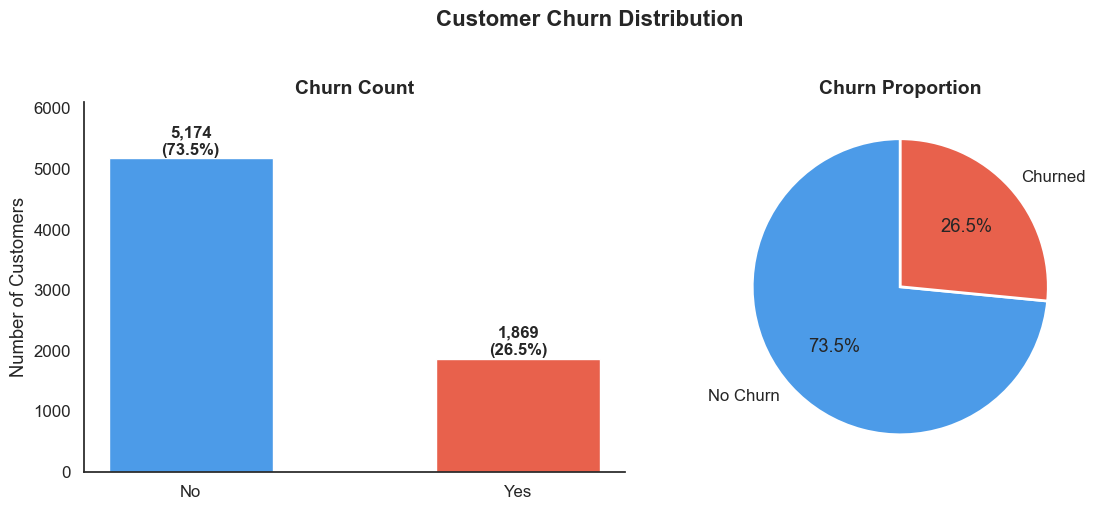

Saved → outputs/01_churn_distribution.png


In [7]:
churn_counts = df['Churn'].value_counts()
churn_rate   = df['Churn_Binary'].mean() * 100
baseline_acc = (1 - df['Churn_Binary'].mean()) * 100

# Interview talking point: baseline accuracy = majority class proportion
print(f"Churn rate         : {churn_rate:.1f}%")
print(f"Baseline accuracy  : {baseline_acc:.1f}%  ← floor our model must beat")
print(f"Churners           : {churn_counts['Yes']:,}")
print(f"Non-churners       : {churn_counts['No']:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values,
            color=[COLOR_NO, COLOR_YES], width=0.5, edgecolor='white')
for i, (label, val) in enumerate(churn_counts.items()):
    axes[0].text(i, val + 60, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.18)

# Pie chart
axes[1].pie(churn_counts.values,
            labels=['No Churn', 'Churned'],
            colors=[COLOR_NO, COLOR_YES],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Customer Churn Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png')
plt.show()
print("Saved → outputs/01_churn_distribution.png")

## 5. Numeric Feature Distributions by Churn
Compare the distribution of `tenure`, `MonthlyCharges`, and `TotalCharges`
between churners and non-churners. Overlapping histograms reveal where the
two groups diverge most.

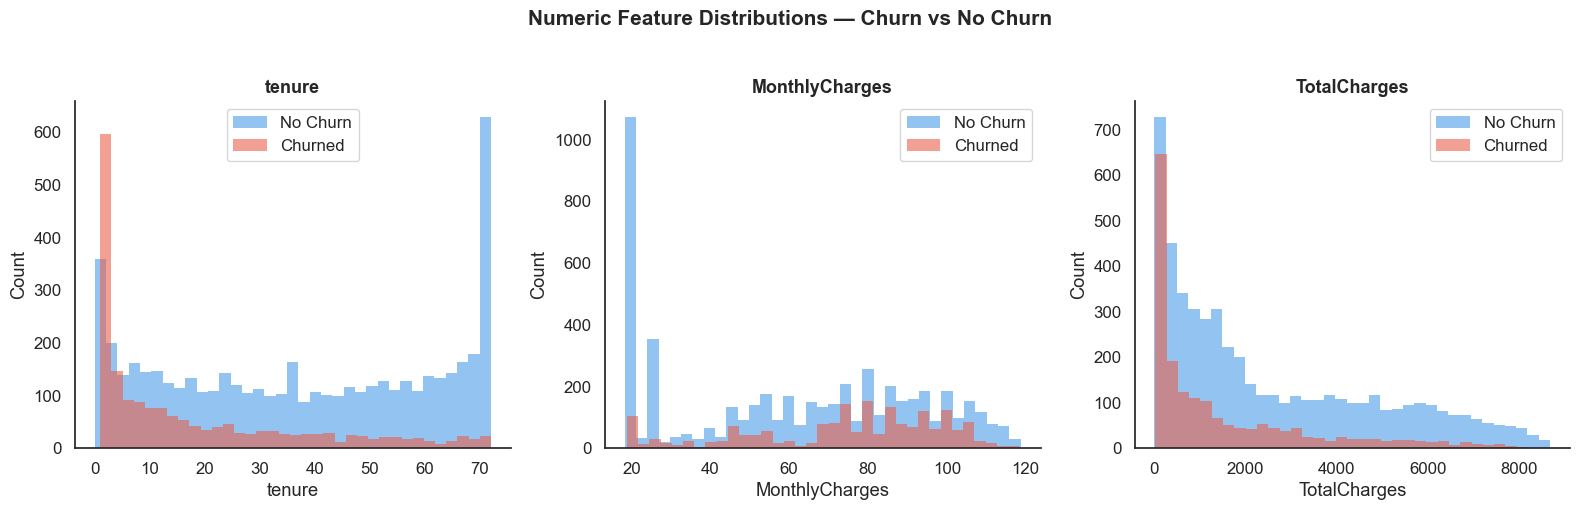

Saved → outputs/02_numeric_distributions.png


In [8]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    for churn_val, label, color in [(0, 'No Churn', COLOR_NO),
                                     (1, 'Churned',  COLOR_YES)]:
        subset = df[df['Churn_Binary'] == churn_val][col]
        ax.hist(subset, bins=35, alpha=0.6, color=color,
                label=label, edgecolor='none')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Feature Distributions — Churn vs No Churn',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_numeric_distributions.png')
plt.show()
print("Saved → outputs/02_numeric_distributions.png")


## Day 2: Deep Churn Pattern Analysis

Now we go deeper — looking at how each categorical and numeric feature
relates to churn rate (not just count). These charts produce the
interview talking points baked into the project.

## 6. Churn Rate by Contract Type
The strongest single predictor in the dataset.

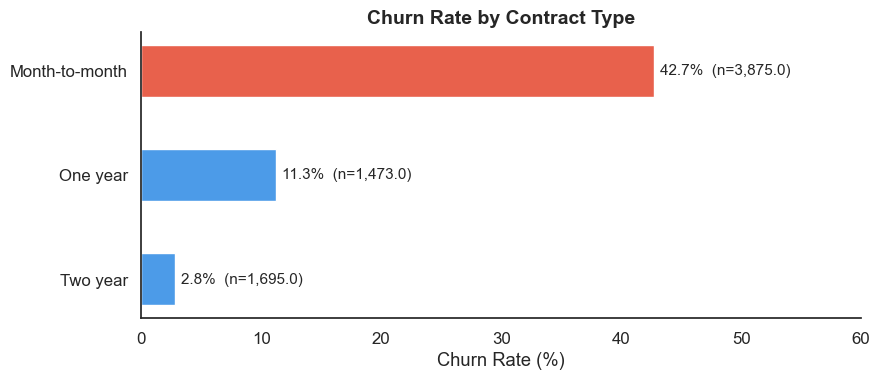

Saved → outputs/03_contract_churn.png


In [12]:
contract_churn = (df.groupby('Contract')['Churn_Binary']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'churn_rate', 'count': 'n_customers'})
                    .sort_values('churn_rate', ascending=True))

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(contract_churn.index,
               contract_churn['churn_rate'] * 100,
               color=[COLOR_YES if r > 0.3 else COLOR_NO
                      for r in contract_churn['churn_rate']],
               edgecolor='white', height=0.5)

for i, (idx, row) in enumerate(contract_churn.iterrows()):
    ax.text(row['churn_rate'] * 100 + 0.5,
            i,
            f"{row['churn_rate']*100:.1f}%  (n={row['n_customers']:,})",
            va='center', fontsize=11)

ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('../outputs/03_contract_churn.png')
plt.show()
print("Saved → outputs/03_contract_churn.png")

## 7. Churn Rate by Tenure Group
Early-life customers are the highest risk. Churn drops sharply after 24 months.

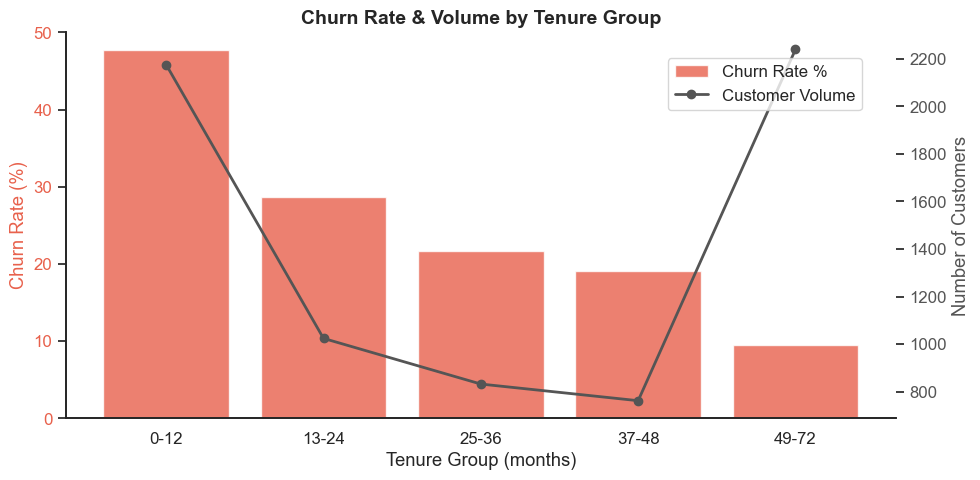

Saved → outputs/04_tenure_churn.png


In [13]:
bins   = [0, 12, 24, 36, 48, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

tenure_churn = (df.groupby('tenure_group', observed=True)['Churn_Binary']
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'churn_rate', 'count': 'n_customers'}))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(tenure_churn.index,
        tenure_churn['churn_rate'] * 100,
        color=COLOR_YES, alpha=0.8, edgecolor='white', label='Churn Rate %')
ax1.set_ylabel('Churn Rate (%)', color=COLOR_YES)
ax1.set_xlabel('Tenure Group (months)')
ax1.tick_params(axis='y', labelcolor=COLOR_YES)

ax2 = ax1.twinx()
ax2.plot(tenure_churn.index,
         tenure_churn['n_customers'],
         color='#555555', marker='o', linewidth=2, label='Customer Volume')
ax2.set_ylabel('Number of Customers', color='#555555')
ax2.tick_params(axis='y', labelcolor='#555555')

ax1.set_title('Churn Rate & Volume by Tenure Group', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('../outputs/04_tenure_churn.png')
plt.show()
print("Saved → outputs/04_tenure_churn.png")

## 8. Churn Rate by Internet Service Type

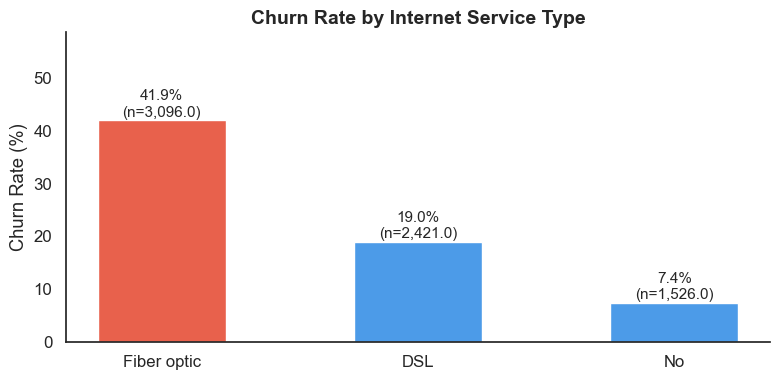

Saved → outputs/05_internet_churn.png


In [14]:
internet_churn = (df.groupby('InternetService')['Churn_Binary']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'churn_rate', 'count': 'n_customers'})
                    .sort_values('churn_rate', ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOR_YES if r > 0.3 else COLOR_NO for r in internet_churn['churn_rate']]
bars = ax.bar(internet_churn.index,
              internet_churn['churn_rate'] * 100,
              color=colors, edgecolor='white', width=0.5)

for bar, (idx, row) in zip(bars, internet_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['churn_rate']*100:.1f}%\n(n={row['n_customers']:,})",
            ha='center', fontsize=11)

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_ylim(0, internet_churn['churn_rate'].max() * 140)
plt.tight_layout()
plt.savefig('../outputs/05_internet_churn.png')
plt.show()
print("Saved → outputs/05_internet_churn.png")

## 9. All Categorical Features — Churn Rate Overview
A 4×4 grid showing churn rate for every categorical column at once.
Color coding: red > 30%, orange > 15%, blue otherwise.

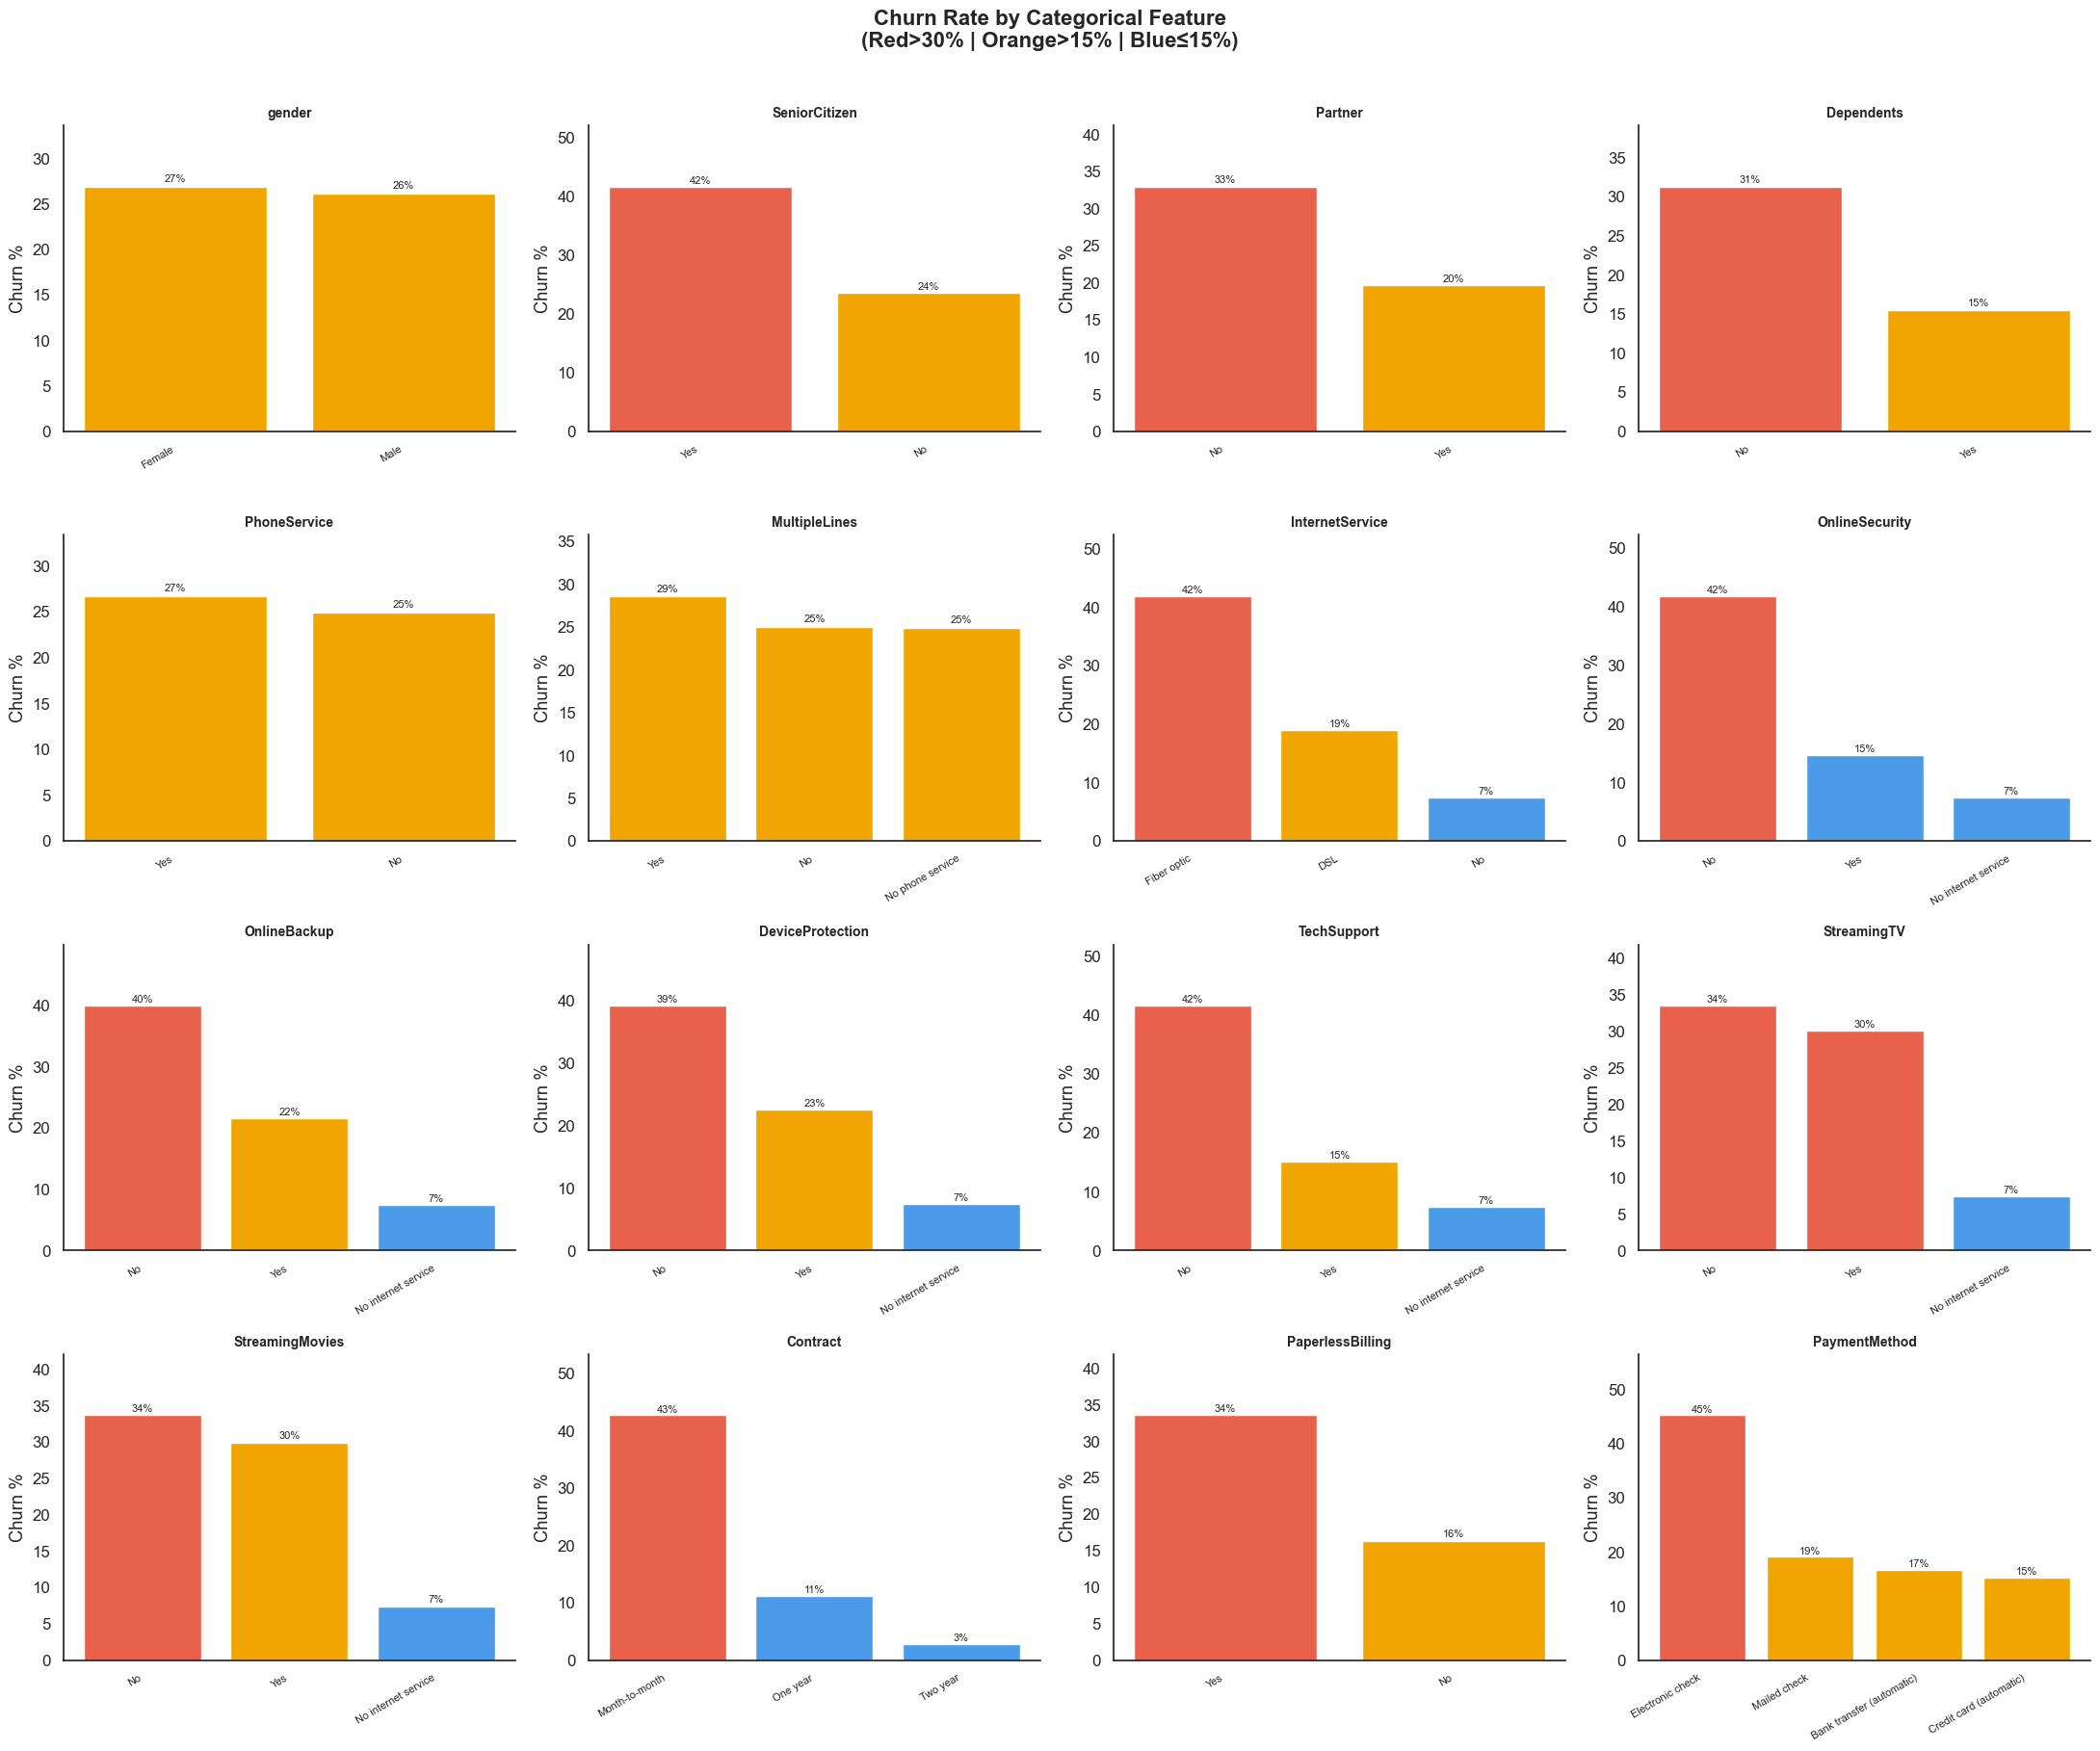

Saved → outputs/06_categorical_churn_overview.png


In [15]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rates = (df.groupby(col)['Churn_Binary'].mean() * 100).sort_values(ascending=False)
    bar_colors = ['#E8614C' if r > 30 else '#F0A500' if r > 15 else COLOR_NO
                  for r in rates.values]
    ax.bar(range(len(rates)), rates.values, color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn %')
    ax.set_ylim(0, max(rates.values) * 1.25)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

plt.suptitle('Churn Rate by Categorical Feature\n(Red>30% | Orange>15% | Blue≤15%)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_categorical_churn_overview.png')
plt.show()
print("Saved → outputs/06_categorical_churn_overview.png")

## 10. Correlation Heatmap — Numeric Features vs Churn

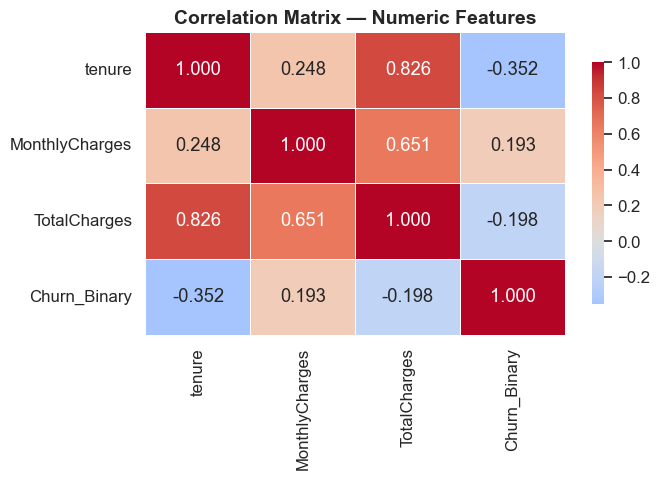


Correlations with Churn_Binary:
  tenure              : -0.352  (↓ lower = more churn)
  TotalCharges        : -0.198  (↓ lower = more churn)
  MonthlyCharges      : +0.193  (↑ higher = more churn)
Saved → outputs/07_correlation_heatmap.png


In [16]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']].copy()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # show full matrix

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png')
plt.show()

print("\nCorrelations with Churn_Binary:")
churn_corr = corr['Churn_Binary'].drop('Churn_Binary').sort_values()
for feat, val in churn_corr.items():
    direction = "↑ higher = more churn" if val > 0 else "↓ lower = more churn"
    print(f"  {feat:20s}: {val:+.3f}  ({direction})")

print("Saved → outputs/07_correlation_heatmap.png")

## 11. Revenue Impact Analysis
Quantify the exact dollar cost of churn — makes the project business-relevant.

**Interview talking point:** Translating model predictions into revenue impact is
what separates a data science project from a business solution. Any stakeholder
understands "$1.67M lost annually" — not everyone understands "26.5% churn rate."

In [17]:
churners    = df[df['Churn_Binary'] == 1]
stayers     = df[df['Churn_Binary'] == 0]

n_churners          = len(churners)
avg_charge_churn    = churners['MonthlyCharges'].mean()
avg_charge_stay     = stayers['MonthlyCharges'].mean()
monthly_rev_lost    = churners['MonthlyCharges'].sum()
annual_rev_lost     = monthly_rev_lost * 12
save_10pct_monthly  = monthly_rev_lost * 0.10

print("=" * 55)
print("       REVENUE IMPACT OF CHURN")
print("=" * 55)
print(f"  Total churners              : {n_churners:,}")
print(f"  Avg monthly charge (churner): ${avg_charge_churn:.2f}")
print(f"  Avg monthly charge (stayer) : ${avg_charge_stay:.2f}")
print(f"  Monthly revenue lost        : ${monthly_rev_lost:,.0f}")
print(f"  Annual revenue lost         : ${annual_rev_lost:,.0f}")
print(f"  Saving 10% of churners saves: ${save_10pct_monthly:,.0f}/month")
print("=" * 55)

# Interview talking point: churners actually pay MORE per month than stayers.
# This means churn is not just a volume problem — we are losing high-value customers.
print("\n⚠️  Churners pay ${:.2f} MORE per month than stayers — these are high-value customers!".format(
    avg_charge_churn - avg_charge_stay))

       REVENUE IMPACT OF CHURN
  Total churners              : 1,869
  Avg monthly charge (churner): $74.44
  Avg monthly charge (stayer) : $61.27
  Monthly revenue lost        : $139,131
  Annual revenue lost         : $1,669,570
  Saving 10% of churners saves: $13,913/month

⚠️  Churners pay $13.18 MORE per month than stayers — these are high-value customers!


## 12. TOP 5 CHURN DRIVERS — Interview Summary Cell
Memorize these numbers. They will come up in every interview.

In [18]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           TOP 5 CHURN DRIVERS FROM EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. CONTRACT TYPE (strongest predictor)                      ║
║     Month-to-month: ~42% churn | 2-year: ~3% churn          ║
║                                                              ║
║  2. TENURE (loyalty effect)                                  ║
║     0-12 months: highest churn | drops sharply after 24mo   ║
║                                                              ║
║  3. INTERNET SERVICE                                         ║
║     Fibre optic: ~42% churn | DSL: ~19% churn               ║
║                                                              ║
║  4. ADD-ON SERVICES (OnlineSecurity / TechSupport)           ║
║     Without: ~41% churn | With: ~15% churn                  ║
║                                                              ║
║  5. MONTHLY CHARGES (counter-intuitive)                      ║
║     Churners pay MORE ($74 avg vs $61 for stayers)          ║
║     → We are losing high-value customers                     ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Monthly revenue at risk : $139,130                          ║
║  Annual revenue at risk  : $1,669,560                        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           TOP 5 CHURN DRIVERS FROM EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. CONTRACT TYPE (strongest predictor)                      ║
║     Month-to-month: ~42% churn | 2-year: ~3% churn          ║
║                                                              ║
║  2. TENURE (loyalty effect)                                  ║
║     0-12 months: highest churn | drops sharply after 24mo   ║
║                                                              ║
║  3. INTERNET SERVICE                                         ║
║     Fibre optic: ~42% churn | DSL: ~19% churn               ║
║                                                              ║
║  4. ADD-ON SERVICES (OnlineSecurity / TechSupport)           ║
║     Without: ~41% churn | With: ~15% churn                  ║
║                            

## 13. Save Clean Dataset
Drop temporary column and save `telco_clean.csv` for Stage 2.

In [19]:
# Drop the temporary binning column — Stage 2 will recreate it properly
df.drop(columns=['tenure_group'], inplace=True)

save_path = '../data/telco_clean.csv'
df.to_csv(save_path, index=False)

print(f"✅ Saved clean dataset → {save_path}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")

print("\n📁 Output PNGs created:")
outputs = [
    'outputs/01_churn_distribution.png',
    'outputs/02_numeric_distributions.png',
    'outputs/03_contract_churn.png',
    'outputs/04_tenure_churn.png',
    'outputs/05_internet_churn.png',
    'outputs/06_categorical_churn_overview.png',
    'outputs/07_correlation_heatmap.png',
]
for f in outputs:
    exists = "✅" if os.path.exists(f'../{f}') else "❌ MISSING"
    print(f"  {exists}  {f}")

print("\n🎉 Stage 1 complete. Ready for Stage 2 — Feature Engineering.")

✅ Saved clean dataset → ../data/telco_clean.csv
   Shape: 7,043 rows × 22 columns
   Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary']

📁 Output PNGs created:
  ✅  outputs/01_churn_distribution.png
  ✅  outputs/02_numeric_distributions.png
  ✅  outputs/03_contract_churn.png
  ✅  outputs/04_tenure_churn.png
  ✅  outputs/05_internet_churn.png
  ✅  outputs/06_categorical_churn_overview.png
  ✅  outputs/07_correlation_heatmap.png

🎉 Stage 1 complete. Ready for Stage 2 — Feature Engineering.
